In [ ]:
!pip install google-cloud-bigquery google-cloud-bigquery-storage pyarrow duckdb -q

from google.colab import auth
auth.authenticate_user()

In [ ]:
import duckdb
from google.cloud import bigquery

project_id = 'ecommerce-lakehouse-prod'
client = bigquery.Client(project=project_id)

extract_query = """
    SELECT
        event_time,
        event_type,
        product_id,
        category_id,
        category_code,
        brand,
        price,
        user_id,
        user_session
    FROM `ecommerce-lakehouse-prod.ecommerce_analytics.stg_ecommerce_cleaned`
    WHERE event_time >= '2019-10-01'
      AND event_time < '2019-10-31'
"""

print("Running query...")

# 🔥 IMPORTANT: Use Storage API (faster + efficient)
arrow_table = client.query(extract_query).to_arrow(
    create_bqstorage_client=True
)

print(f"Rows: {arrow_table.num_rows:,}, Columns: {arrow_table.num_columns}")

Running query...
Rows: 34,778,062, Columns: 9


In [ ]:
con = duckdb.connect()

con.register("bq_data", arrow_table)

# Test query
con.execute("SELECT COUNT(*) FROM bq_data").fetchall()

[(34778062,)]

In [ ]:
con.execute("""
    COPY bq_data TO 'ecommerce_sample.parquet' (FORMAT PARQUET)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#   The Margin Bleed: "Who are the 'Safe Buyers' we are accidentally giving discounts to?"

# power bi

In [ ]:
path = '/content/drive/MyDrive/A_CART/ecommerce_sample.parquet'

In [ ]:
import duckdb
import pandas as pd
con = duckdb.connect()   # create connection

In [ ]:
con.execute(f"""
    SELECT count(*)
    FROM '{path}'

""").fetchdf()

,count_star()
0,34778062


**The "Post-Cart Bounce" Metric (The Golden Rule)**
* **The Parameter:** count(views_after_carting)

* **The Logic**  When a user adds an item to their cart, what do they do next?
 > If they go back to the catalog to view 5 more items in the same category, they are hesitant and comparing prices.

     > If the count is zero (meaning they went view -> cart -> checkout_initiation), they are a Safe Buyer.



**Category Focus (The "Sniper" Metric)**

* The Parameter: count(distinct category_code) per user_session

* The Logic: Window shoppers browse "Electronics", then "Apparel", then "Home Goods". They are bored. A Safe Buyer searches "Apple AirPods Pro", looks at maybe two variations, and adds one to the cart.

* The Threshold: If distinct_categories <= 2, the probability of being a Safe Buyer skyrockets.

**Action Velocity (Time-to-Cart)**

* **The Parameter:** time_diff(first_view_event, cart_event)

* **The Logic:** How long did it take them to decide? If a user adds a $200 item to their cart within 90 seconds of starting their session, they likely researched the product off-site (e.g., watched a YouTube review) and came to your store solely to execute the purchase.

* **The Threshold:** Fast velocity = High Intent = Safe Buyer. Suppress the discount pop-up.

**The Price Insensitivity Flag**
* **The Parameter:** item_price vs avg_category_price

* **The Logic:** If a user immediately carts an item that is in the top 90th percentile of pricing for that category (e.g., the most expensive TV), they are less sensitive to price. Budget-conscious (hesitant) buyers sort by "Price: Low to High."

* **The Action:** Never offer a blanket percentage discount on premium, high-intent cart additions.

eg,

* Customer A walks straight over to the budget section, looks at five different $300 TVs, and pulls up reviews on his phone. He is stressed about the cost.

* Customer B walks straight to the wall, points at the absolute most expensive, top-of-the-line $3,500 OLED 8K TV, and says, "Wrap it up."

* 0 means: "This user added a normal or cheap item to their cart. They are probably hunting for a bargain. (Treat them normally)."

* 1 means: "This user just added an item that is in the top 10% most expensive products in this category. They are a premium buyer. (DO NOT give them a discount)."

In [ ]:
q=f"""
WITH session_agg AS (
    SELECT
        user_id,
        user_session,

        -- flags
        MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase,

        -- value aggregations
        SUM(CASE WHEN event_type = 'view' THEN price ELSE 0 END) AS total_viewed_value,
        SUM(CASE WHEN event_type = 'cart' THEN price ELSE 0 END) AS net_cart_value,
        SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_purchased_value

    FROM '{path}'
    GROUP BY user_id, user_session
)

SELECT *
FROM session_agg


"""
df= duckdb.query(q).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
df.count()

,0
user_id,5367916
user_session,5367916
has_view,5367916
has_cart,5367916
has_purchase,5367916
total_viewed_value,5367916
net_cart_value,5367916
total_purchased_value,5367916


In [ ]:
df.head()

,user_id,user_session,has_view,has_cart,has_purchase,total_viewed_value,net_cart_value,total_purchased_value
0,517416949,dde246d1-386b-4ce8-9a5b-71f5c94f622c,1,0,0,463.28,0.0,0.0
1,536086471,db0beea6-5518-4aac-a9c1-970b731ed266,1,0,0,992.49,0.0,0.0
2,514615078,cd4ec98c-0686-429d-b4b3-c47ab13b366c,1,0,0,10537.58,0.0,0.0
3,522500200,e8a3242a-870b-4fea-861e-9585ea847a86,1,0,0,136.80,0.0,0.0
4,560265505,f753d719-6ad9-4df9-8549-5cc6eaf6ba7d,1,0,0,72.08,0.0,0.0


In [ ]:
import duckdb
import pandas as pd

q = f"""
WITH session_events AS (
    -- STEP 1: Establish the timeline
    SELECT
        user_id,
        user_session,
        event_type,
        price,
        event_time::TIMESTAMP AS event_time, -- Cast to TIMESTAMP for time math
        category_code,

        -- Find the exact timestamp of the first 'cart' event in this specific session
        MIN(CASE WHEN event_type = 'cart' THEN event_time::TIMESTAMP END) OVER (PARTITION BY user_session) AS first_cart_time,

        -- Find the exact timestamp of the very first 'view' event to mark the session start
        MIN(CASE WHEN event_type = 'view' THEN event_time::TIMESTAMP END) OVER (PARTITION BY user_session) AS first_view_time

    FROM '{path}'
),

session_agg AS (
    -- STEP 2: Aggregate based on the timeline
    SELECT
        user_id,
        user_session,

        -- Standard Flags
        MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase,

        -- Value Aggregations
        SUM(CASE WHEN event_type = 'view' THEN price ELSE 0 END) AS total_viewed_value,
        SUM(CASE WHEN event_type = 'cart' THEN price ELSE 0 END) AS net_cart_value,
        SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_purchased_value,

        -- Feature 1: The "Research Depth" Feature (NEW)
        -- Count views only if they happened BEFORE the first cart addition
        SUM(CASE WHEN event_type = 'view' AND event_time < first_cart_time THEN 1 ELSE 0 END) AS views_before_cart,

        -- Feature 2: The "Hesitation" Feature
        -- Count views only if they happened AFTER the first cart addition
        SUM(CASE WHEN event_type = 'view' AND event_time > first_cart_time THEN 1 ELSE 0 END) AS views_after_cart,

        -- Feature 3: The "Focus" Feature
        COUNT(DISTINCT category_code) AS unique_categories_viewed,

        -- Feature 4: The "Time-to-Decision" Feature (Raw Seconds for ML)
        MAX(date_diff('second', first_view_time, first_cart_time)) AS time_view_to_cart_sec

    FROM session_events
    GROUP BY user_id, user_session
)

-- STEP 3: Final Output with Formatting
SELECT
    *,
    -- Format the raw seconds into a clean d:h:m:s string for visualization
    CASE
        WHEN time_view_to_cart_sec IS NOT NULL AND time_view_to_cart_sec >= 0 THEN
            CAST(time_view_to_cart_sec / 86400 AS INT)::VARCHAR || 'd:' ||
            LPAD(CAST((time_view_to_cart_sec % 86400) / 3600 AS INT)::VARCHAR, 2, '0') || 'h:' ||
            LPAD(CAST((time_view_to_cart_sec % 3600) / 60 AS INT)::VARCHAR, 2, '0') || 'm:' ||
            LPAD(CAST(time_view_to_cart_sec % 60 AS INT)::VARCHAR, 2, '0') || 's'
        ELSE '0d:00h:00m:00s'
    END AS time_view_to_cart_formatted
FROM session_agg
WHERE has_cart = 1 -- Keeping our focus strictly on the cart funnel
"""

final_result = duckdb.query(q).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
final_result.head(10)

,user_id,user_session,has_view,has_cart,has_purchase,total_viewed_value,net_cart_value,total_purchased_value,views_before_cart,views_after_cart,unique_categories_viewed,time_to_cart_sec,time_to_cart_formatted
0,519650870,0032e3c0-5d0d-4896-be83-95d4c1b0dd95,1,1,0,159.90,159.90,0.00,1.0,0.0,1,57,0d:00h:01m:57s
1,519661560,0038b269-76fd-43fb-8335-52eb4ffbaf24,1,1,0,8833.37,287.97,0.00,5.0,14.0,1,317,0d:00h:05m:17s
2,553532823,00cd73c7-248e-46ff-b1e0-42a5ec72c192,1,1,0,5576.35,167.29,0.00,17.0,7.0,2,7869,0d:02h:11m:09s
3,556781719,018ff5be-a4b4-4654-8094-20871e4ddb20,1,1,0,230.13,76.71,0.00,1.0,2.0,1,7,0d:00h:00m:07s
4,549468506,01fdae8f-08e7-424f-88c6-eb6deb2cd2ae,1,1,0,131.66,131.66,0.00,1.0,0.0,1,10,0d:00h:00m:10s
5,518785401,022e9f51-0a61-4817-b7eb-38ed92e34361,1,1,1,452.87,214.98,107.49,2.0,3.0,1,26,0d:00h:00m:26s
6,512414095,02657803-5345-40e7-9ce3-09b694e11801,1,1,0,873.87,873.87,0.00,1.0,0.0,1,6,0d:00h:00m:06s
7,549830353,027b9d89-a188-44af-ac2f-87ed450877d0,1,1,1,263.52,131.76,131.76,1.0,1.0,1,51,0d:00h:01m:51s
8,515064223,038d0101-5cd2-4230-9910-0d2a5e7b93fa,1,1,0,308.60,308.60,0.00,1.0,0.0,1,1,0d:00h:00m:01s
9,533763286,03aab2a0-dcdc-4314-a09e-343992d2fcfb,1,1,1,320.48,160.24,160.24,1.0,1.0,1,34,0d:00h:01m:34s


In [ ]:
import duckdb
import pandas as pd

q = f"""
WITH raw_data AS (
    -- STEP 1: Load data once into memory to avoid multiple disk reads
    SELECT
        user_id,
        user_session,
        event_type,
        price,
        event_time::TIMESTAMP AS event_time,
        category_code
    FROM '{path}'
),

category_intelligence AS (
    -- STEP 2: The "Price Insensitivity" Baseline
    -- Calculate the 90th percentile price and average price for EVERY category across the whole store
    SELECT
        category_code,
        -- quantile_cont is DuckDB's function for calculating percentiles
        quantile_cont(price, 0.90) AS category_p90_price,
        AVG(price) AS category_avg_price
    FROM raw_data
    WHERE category_code IS NOT NULL
    GROUP BY category_code
),

session_events AS (
    -- STEP 3: Establish the timeline AND inject the Category Intelligence
    SELECT
        r.user_id,
        r.user_session,
        r.event_type,
        r.price,
        r.event_time,
        r.category_code,
        c.category_p90_price, -- Bringing the 90th percentile benchmark into the session
        c.category_avg_price,

        MIN(CASE WHEN r.event_type = 'cart' THEN r.event_time END) OVER (PARTITION BY r.user_session) AS first_cart_time,
        MIN(CASE WHEN r.event_type = 'view' THEN r.event_time END) OVER (PARTITION BY r.user_session) AS first_view_time

    FROM raw_data r
    LEFT JOIN category_intelligence c ON r.category_code = c.category_code
),

session_agg AS (
    -- STEP 4: Aggregate based on the timeline
    SELECT
        user_id,
        user_session,

        MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase,

        SUM(CASE WHEN event_type = 'view' THEN price ELSE 0 END) AS total_viewed_value,
        SUM(CASE WHEN event_type = 'cart' THEN price ELSE 0 END) AS net_cart_value,
        SUM(CASE WHEN event_type = 'purchase' THEN price ELSE 0 END) AS total_purchased_value,

        SUM(CASE WHEN event_type = 'view' AND event_time < first_cart_time THEN 1 ELSE 0 END) AS views_before_cart,
        SUM(CASE WHEN event_type = 'view' AND event_time > first_cart_time THEN 1 ELSE 0 END) AS views_after_cart,
        COUNT(DISTINCT category_code) AS unique_categories_viewed,
        MAX(date_diff('second', first_view_time, first_cart_time)) AS time_to_cart_sec,



    FROM session_events
    GROUP BY user_id, user_session
)

-- STEP 5: Final Output with Formatting
SELECT
    *,
    CASE
        WHEN time_to_cart_sec IS NOT NULL AND time_to_cart_sec >= 0 THEN
            CAST(time_to_cart_sec / 86400 AS INT)::VARCHAR || 'd:' ||
            LPAD(CAST((time_to_cart_sec % 86400) / 3600 AS INT)::VARCHAR, 2, '0') || 'h:' ||
            LPAD(CAST((time_to_cart_sec % 3600) / 60 AS INT)::VARCHAR, 2, '0') || 'm:' ||
            LPAD(CAST(time_to_cart_sec % 60 AS INT)::VARCHAR, 2, '0') || 's'
        ELSE '0d:00h:00m:00s'
    END AS time_to_cart_formatted
FROM session_agg
WHERE has_cart = 1
"""

final_result2 = duckdb.query(q).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
final_result2.to_parquet(
    "/content/drive/MyDrive/A_CART/final_result2.parquet",
    engine="pyarrow",
    index=False
)

In [ ]:
import pandas as pd

# 1. Segment the data
# Abandoners: Put something in the cart but didn't buy
abandoners = df[(df['has_cart'] == 1) & (df['has_purchase'] == 0)]

# Converters: Put something in the cart and completed the purchase
converters = df[(df['has_cart'] == 1) & (df['has_purchase'] == 1)]

# 2. Generate the Overview Table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Sessions',
        'Avg Net Cart Value',
        'Avg Views After Cart (Hesitation)',
        'Max Views After Cart',
        'Avg Total Viewed Value'
    ],
    'Abandoners (Target=0)': [
        len(abandoners),
        abandoners['net_cart_value'].mean(),
        abandoners['views_after_cart'].mean(),
        abandoners['views_after_cart'].max(),
        abandoners['total_viewed_value'].mean()
    ],
    'Converters (Target=1)': [
        len(converters),
        converters['net_cart_value'].mean(),
        converters['views_after_cart'].mean(),
        converters['views_after_cart'].max(),
        converters['total_viewed_value'].mean()
    ]
})

print("--- Segment Comparison Overview ---")
print(summary_stats.to_string(index=False))

# 3. Quick Peek at the raw distribution
print("\n--- Abandoners Sample ---")
print(abandoners.head())

print("\n--- Converters Sample ---")
print(converters.head())

--- Segment Comparison Overview ---
                           Metric  Abandoners (Target=0)  Converters (Target=1)
                   Total Sessions          260825.000000          260833.000000
               Avg Net Cart Value             464.419498             561.434722
Avg Views After Cart (Hesitation)               3.073988               2.201547
             Max Views After Cart             134.000000             139.000000
           Avg Total Viewed Value            1983.189298            1653.064199

--- Abandoners Sample ---
      user_id                          user_session  has_view  has_cart  \
56  555911662  02924838-f7d8-4e90-a7b2-1d2da3a09145         1         1   
59  563992249  02bd1334-afff-4cc8-a051-f7385bf244e0         1         1   
61  560210760  02e78201-3f5b-4306-8b24-1330ac6cb2c7         1         1   
69  549516829  035f4e7f-21bf-4119-9438-b2dcbe5cddba         1         1   
72  514446436  039e5b9c-4b08-499a-bec1-1bbcbb2fb25a         1         1   

    ha

--- Enterprise Data Funnel Overview ---
Total Raw Sessions:            5,367,916
Sessions with Cart Activity:   521,658 (9.72% of total)
--------------------------------------------------
🔴 Cart Abandoners (Target=1): 260,825 (50.00% of cart sessions)
🟢 Cart Converters (Target=0):  260,833 (50.00% of cart sessions)


/tmp/ipykernel_7487/1907216663.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=cart_sessions_df, x='has_purchase', palette=['#e74c3c', '#2ecc71'])


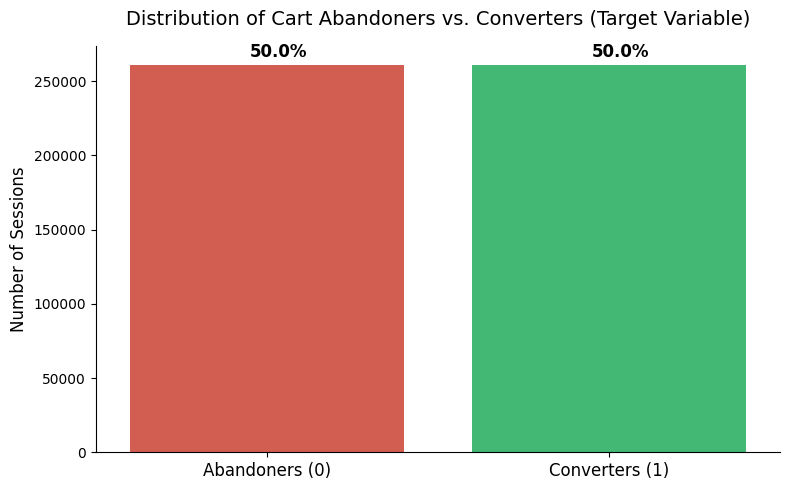

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is currently named 'df'

# 1. The Funnel Breakdown
total_sessions = len(df)

# We ONLY care about sessions where a cart action occurred
cart_sessions_df = df[df['has_cart'] == 1]
total_cart_sessions = len(cart_sessions_df)

# Define our two target groups from the cart sessions
abandoners = len(cart_sessions_df[cart_sessions_df['has_purchase'] == 0])
converters = len(cart_sessions_df[cart_sessions_df['has_purchase'] == 1])

# 2. Calculate Business Metrics (Percentages)
cart_rate = (total_cart_sessions / total_sessions) * 100
if total_cart_sessions > 0:
    abandon_rate = (abandoners / total_cart_sessions) * 100
    conversion_rate = (converters / total_cart_sessions) * 100
else:
    abandon_rate, conversion_rate = 0, 0

# 3. Executive Summary Printout
print("="*50)
print(f"--- Enterprise Data Funnel Overview ---")
print("="*50)
print(f"Total Raw Sessions:            {total_sessions:,}")
print(f"Sessions with Cart Activity:   {total_cart_sessions:,} ({cart_rate:.2f}% of total)")
print("-" * 50)
print(f"🔴 Cart Abandoners (Target=1): {abandoners:,} ({abandon_rate:.2f}% of cart sessions)")
print(f"🟢 Cart Converters (Target=0):  {converters:,} ({conversion_rate:.2f}% of cart sessions)")
print("="*50)

# 4. Generate Portfolio-Ready Visualization
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=cart_sessions_df, x='has_purchase', palette=['#e74c3c', '#2ecc71'])

# Add percentage labels to the top of the bars
total = len(cart_sessions_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), size=12, weight='bold')

plt.title('Distribution of Cart Abandoners vs. Converters (Target Variable)', fontsize=14, pad=15)
plt.xticks([0, 1], ['Abandoners (0)', 'Converters (1)'], fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('')
# Hide the top and right spines for a cleaner look
sns.despine()
plt.tight_layout()
plt.show()

--- FULL 5.3 MILLION SESSION DISTRIBUTION ---
                               Total Sessions  Percentage (%)
user_segment                                                 
1. View Only (Window Shopper)         4846258           90.28
3. Purchaser                           260833            4.86
2. Cart Abandoner                      260825            4.86


/tmp/ipykernel_7487/93399489.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


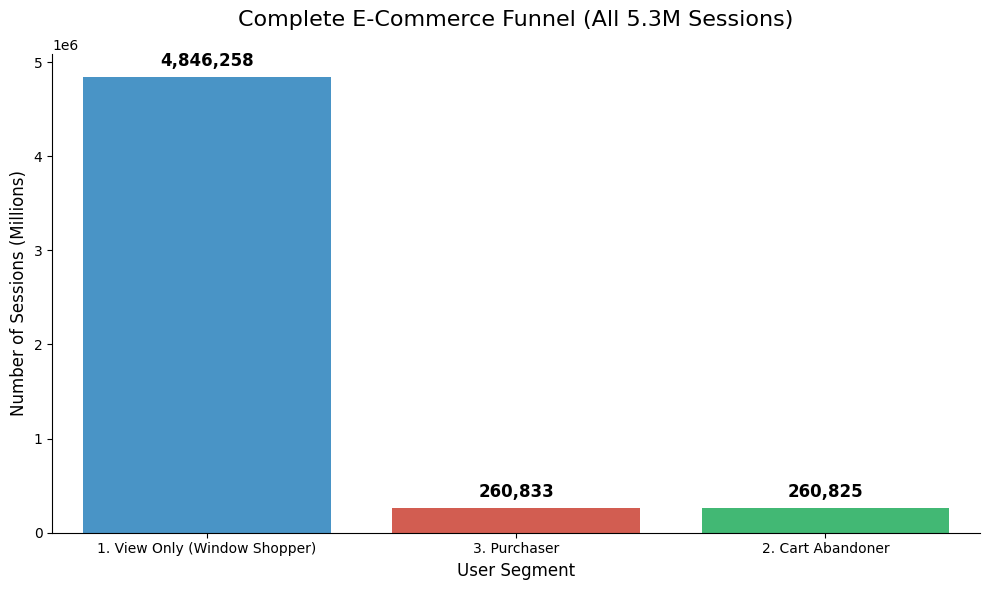

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vectorized Categorization for 5.3 Million Rows
# This is 100x faster than using .apply()
conditions = [
    (df['has_purchase'] == 1),                                     # Bought something
    (df['has_cart'] == 1) & (df['has_purchase'] == 0),             # Carted but didn't buy
    (df['has_cart'] == 0) & (df['has_purchase'] == 0)              # Only viewed items
]

choices = [
    '3. Purchaser',
    '2. Cart Abandoner',
    '1. View Only (Window Shopper)'
]

# Create the new segment column
df['user_segment'] = np.select(conditions, choices, default='Unknown')

# 2. Calculate the Full Distribution
distribution = df['user_segment'].value_counts()
percentages = df['user_segment'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Total Sessions': distribution,
    'Percentage (%)': percentages
}).round(2)

print("="*60)
print("--- FULL 5.3 MILLION SESSION DISTRIBUTION ---")
print("="*60)
print(summary_df)
print("="*60)

# 3. Visualize the Complete Funnel
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=summary_df.index,
    y=summary_df['Total Sessions'],
    palette=['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green
)

plt.title('Complete E-Commerce Funnel (All 5.3M Sessions)', fontsize=16, pad=20)
plt.ylabel('Number of Sessions (Millions)', fontsize=12)
plt.xlabel('User Segment', fontsize=12)

# Add exact numbers on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, weight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
next_path= '/content/drive/MyDrive/A_CART/final_result2.parquet'

In [ ]:
import duckdb

In [ ]:
q=f"""
select count(*) from '{next_path}'
"""


result = duckdb.query(q).df()
result

,count_star()
0,521658


In [ ]:
q=f"""
select *
from '{next_path}'
limit 10
"""


result = duckdb.query(q).df()
result

,user_id,user_session,has_view,has_cart,has_purchase,total_viewed_value,net_cart_value,total_purchased_value,views_before_cart,views_after_cart,unique_categories_viewed,time_to_cart_sec,is_premium_shopper,time_to_cart_formatted
0,521357357,00837a4b-32c3-4232-9b2f-fe59fdfa21b6,1,1,0,575.79,575.79,0.00,1.0,0.0,1,7,0,0d:00h:00m:07s
1,513236715,0133b664-e594-4e0e-bc63-24ca27f45766,1,1,0,49.44,49.44,0.00,1.0,3.0,1,52,0,0d:00h:01m:52s
2,526002865,0144a161-d76a-499e-9185-92e09266d1de,1,1,0,13.62,13.62,0.00,1.0,0.0,1,29,0,0d:00h:00m:29s
3,518478735,0148733d-23fb-4efc-8b64-af90e8743d88,1,1,0,689.59,129.99,0.00,1.0,4.0,1,51,0,0d:00h:01m:51s
4,514180866,01c9648d-f806-4197-a617-536383547a7d,1,1,0,2883.78,20.57,0.00,3.0,17.0,3,122,0,0d:00h:02m:02s
5,545374580,0275c486-f09b-46e0-890e-27aad0e621b1,1,1,0,669.20,334.60,0.00,2.0,0.0,1,129,0,0d:00h:02m:09s
6,512735874,03b13b60-1014-422d-bfda-f25fc1504df4,1,1,1,3692.50,1334.14,975.57,1.0,8.0,3,36,0,0d:00h:01m:36s
7,554924607,068fee1d-00e5-4dd4-b7dc-32a3c073f506,1,1,1,534.88,267.44,267.44,1.0,1.0,1,5,0,0d:00h:00m:05s
8,519114840,08379eed-0b1c-4e29-8cee-cee4744c33bd,1,1,1,172.19,172.19,172.19,1.0,0.0,1,40,0,0d:00h:01m:40s
9,513609344,08875397-7be2-4eda-b131-5d0d3bb2262f,1,1,0,4632.54,1544.18,0.00,2.0,1.0,1,114,1,0d:00h:02m:54s


In [ ]:
q=f"""
select *
from '{next_path}'
limit 20
"""


result = duckdb.query(q).df()
result.to_csv('result.csv', index=False)

# overall

# time view to cart

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

THE DISCRETE TIME BUCKETS (ADDS UP TO 100%)
                           Time Bucket  User Count  Percentage of Users (%)
              1. Under 1 Min (Snipers)      260507                    49.99
          2. 1 to 3 Mins (Fast Buyers)      122594                    23.52
              3. 3 to 5 Mins (Average)       44829                     8.60
            4. 5 to 10 Mins (Hesitant)       45710                     8.77
               5. 10 to 30 Mins (Slow)       34657                     6.65
6. 30+ Mins (Distracted/Left Tab Open)       10476                     2.01
Total Percentage: 100%


/tmp/ipykernel_4509/3983617668.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


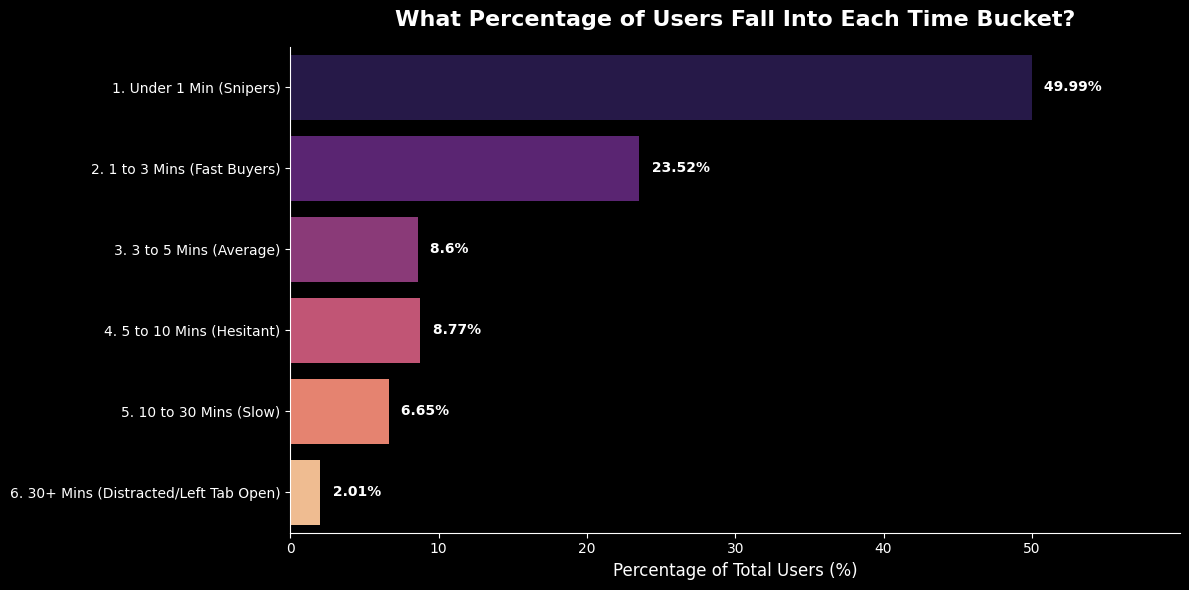

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for a clean portfolio look
plt.style.use('dark_background')

# 1. Load your data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# Drop nulls just in case, and convert seconds to minutes
cart_times = df['time_to_cart_sec'].dropna()
time_in_mins = cart_times / 60

# ==========================================
# 2. CREATE THE DISCRETE BUCKETS
# ==========================================
# We define hard start and stop points. A user can only be in ONE bucket.
bins = [0, 1, 3, 5, 10, 30, np.inf]
labels = [
    '1. Under 1 Min (Snipers)',
    '2. 1 to 3 Mins (Fast Buyers)',
    '3. 3 to 5 Mins (Average)',
    '4. 5 to 10 Mins (Hesitant)',
    '5. 10 to 30 Mins (Slow)',
    '6. 30+ Mins (Distracted/Left Tab Open)'
]

# Use pd.cut to assign every single user into exactly one bucket
bucketed_data = pd.cut(time_in_mins, bins=bins, labels=labels)

# ==========================================
# 3. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
# Count how many users are in each bucket
bucket_counts = bucketed_data.value_counts().reset_index()
bucket_counts.columns = ['Time Bucket', 'User Count']

# Calculate the clean percentage (This WILL add up to 100%)
total_users = len(cart_times)
bucket_counts['Percentage of Users (%)'] = (bucket_counts['User Count'] / total_users * 100).round(2)

# Sort the table logically from fastest to slowest
bucket_counts = bucket_counts.sort_values('Time Bucket').reset_index(drop=True)

print("\n" + "="*60)
print("THE DISCRETE TIME BUCKETS (ADDS UP TO 100%)")
print("="*60)
print(bucket_counts.to_string(index=False))
print("="*60)
print(f"Total Percentage: {bucket_counts['Percentage of Users (%)'].sum():.0f}%")

# ==========================================
# 4. THE VISUAL EDA (THE DASHBOARD CHART)
# ==========================================
plt.figure(figsize=(12, 6))

# Create a horizontal bar chart
ax = sns.barplot(
    data=bucket_counts,
    x='Percentage of Users (%)',
    y='Time Bucket',
    palette='magma'
)

# Add Titles and Labels
plt.title('What Percentage of Users Fall Into Each Time Bucket?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Total Users (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the end of each bar
for index, value in enumerate(bucket_counts['Percentage of Users (%)']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

# Extend the x-axis slightly so the text doesn't get cut off
plt.xlim(0, bucket_counts['Percentage of Users (%)'].max() + 10)

# Remove top and right borders for a cleaner look
sns.despine()
plt.tight_layout()
plt.show()

# unique category code

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

CATEGORY EXPLORATION PROOF: VOLUME VS. INTENT
Category_Bucket  User_Count  % of Total Users  Conversion_Rate (%)
              1      444128             85.14                51.14
              2       54775             10.50                46.01
              3       14155              2.71                40.26
              4        4905              0.94                34.27
             5+        3695              0.71                30.12


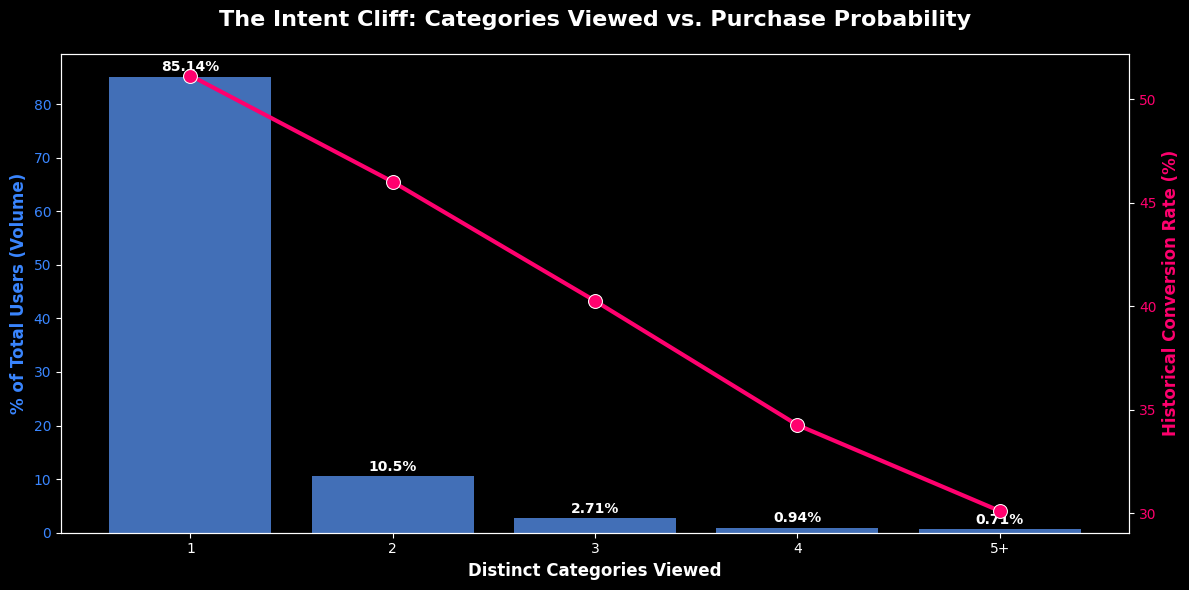

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme for the portfolio
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# Ensure the columns exist.
# (If your column is named differently, change 'unique_categories_viewed' below)
cat_col = 'unique_categories_viewed'

# Cap the extreme window shoppers at "5+" to keep the dashboard clean
df['Category_Bucket'] = df[cat_col].apply(lambda x: str(int(x)) if x < 5 else '5+')

# ==========================================
# 2. CALCULATE VOLUME & CONVERSION RATE
# ==========================================
# We want to know: How many people are in this bucket? And what % of them actually bought?
summary = df.groupby('Category_Bucket').agg(
    User_Count=('user_session', 'count'), # Or whatever your unique ID column is
    # Assuming you have a 'has_purchase' (1/0) column to prove the cliff:
    Conversion_Rate=('has_purchase', 'mean')
).reset_index()

# Calculate the percentage of total users
total_users = summary['User_Count'].sum()
summary['% of Total Users'] = (summary['User_Count'] / total_users * 100).round(2)
summary['Conversion_Rate (%)'] = (summary['Conversion_Rate'] * 100).round(2)

# Sort logically (1, 2, 3, 4, 5+)
summary['Sort_Key'] = summary['Category_Bucket'].replace('5+', 5).astype(int)
summary = summary.sort_values('Sort_Key').drop(columns=['Sort_Key'])

print("\n" + "="*70)
print("CATEGORY EXPLORATION PROOF: VOLUME VS. INTENT")
print("="*70)
print(summary[['Category_Bucket', 'User_Count', '% of Total Users', 'Conversion_Rate (%)']].to_string(index=False))
print("="*70)

# ==========================================
# 3. THE SENIOR DUAL-AXIS VISUALIZATION
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: The Volume (Bar Chart)
sns.barplot(
    data=summary,
    x='Category_Bucket',
    y='% of Total Users',
    color='#3a86ff', # A nice corporate blue
    alpha=0.8,
    ax=ax1
)
ax1.set_xlabel('Distinct Categories Viewed', fontsize=12, fontweight='bold')
ax1.set_ylabel('% of Total Users (Volume)', fontsize=12, color='#3a86ff', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#3a86ff')

# Add the percentage labels on the bars
for index, row in summary.iterrows():
    ax1.text(index, row['% of Total Users'] + 1, f"{row['% of Total Users']}%", color='white', ha="center", fontweight='bold')

# Axis 2: The Conversion Rate (Line Chart)
ax2 = ax1.twinx() # This shares the X-axis but creates a new Y-axis on the right
sns.lineplot(
    data=summary,
    x='Category_Bucket',
    y='Conversion_Rate (%)',
    color='#ff006e', # A striking pink/red for the cliff
    marker='o',
    markersize=10,
    linewidth=3,
    ax=ax2
)
ax2.set_ylabel('Historical Conversion Rate (%)', fontsize=12, color='#ff006e', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff006e')

# Add Titles and Clean up
plt.title('The Intent Cliff: Categories Viewed vs. Purchase Probability', fontsize=16, fontweight='bold', pad=20)
plt.grid(False) # Turn off grid to avoid visual clutter with dual axes
plt.tight_layout()
plt.show()

# view after cart doubt

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

THE FINAL PROOF: POST-CART HESITATION VS. CONVERSION
Post_Cart_Views  User_Count  % of Total Users  Conversion_Rate (%)
              0      154477             29.61                52.82
              1      156591             30.02                52.93
              2       66106             12.67                52.06
              3       38430              7.37                48.12
              4       24551              4.71                45.98
             5+       81503             15.62                39.46


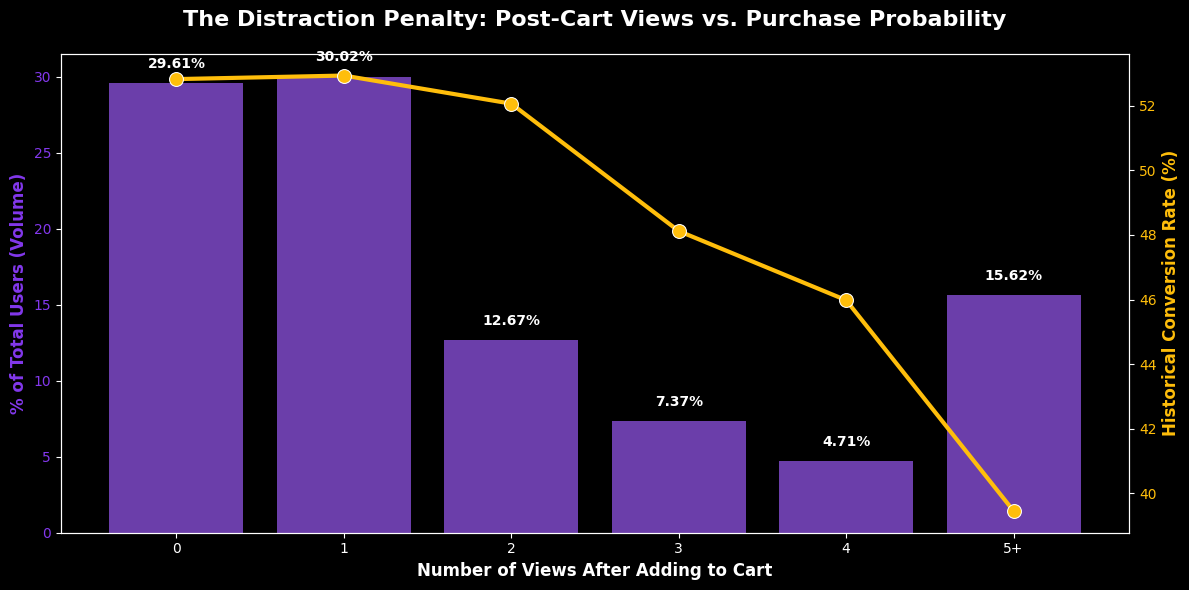

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme for the portfolio
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# Verify the column name (ensure it matches exactly what you named it in your SQL)
view_col = 'views_after_cart' # or 'views_after_cart'

# We cap this at "5+" because anything beyond 5 is just a severe window shopper
df['Post_Cart_Views'] = df[view_col].apply(lambda x: str(int(x)) if x < 5 else '5+')

# ==========================================
# 2. CALCULATE VOLUME & CONVERSION RATE
# ==========================================
summary = df.groupby('Post_Cart_Views').agg(
    User_Count=('user_session', 'count'),
    # This calculates what percentage of people in this bucket actually bought
    Conversion_Rate=('has_purchase', 'mean')
).reset_index()

# Calculate the percentage of total users in each bucket
total_users = summary['User_Count'].sum()
summary['% of Total Users'] = (summary['User_Count'] / total_users * 100).round(2)
summary['Conversion_Rate (%)'] = (summary['Conversion_Rate'] * 100).round(2)

# Sort logically (0, 1, 2, 3, 4, 5+)
summary['Sort_Key'] = summary['Post_Cart_Views'].replace('5+', 5).astype(int)
summary = summary.sort_values('Sort_Key').drop(columns=['Sort_Key'])

print("\n" + "="*70)
print("THE FINAL PROOF: POST-CART HESITATION VS. CONVERSION")
print("="*70)
print(summary[['Post_Cart_Views', 'User_Count', '% of Total Users', 'Conversion_Rate (%)']].to_string(index=False))
print("="*70)

# ==========================================
# 3. THE SENIOR DUAL-AXIS VISUALIZATION
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: The Volume (Bar Chart - Purple)
sns.barplot(
    data=summary,
    x='Post_Cart_Views',
    y='% of Total Users',
    color='#8338ec',
    alpha=0.8,
    ax=ax1
)
ax1.set_xlabel('Number of Views After Adding to Cart', fontsize=12, fontweight='bold')
ax1.set_ylabel('% of Total Users (Volume)', fontsize=12, color='#8338ec', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#8338ec')

# Add the percentage labels on the bars
for index, row in summary.iterrows():
    ax1.text(index, row['% of Total Users'] + 1, f"{row['% of Total Users']}%", color='white', ha="center", fontweight='bold')

# Axis 2: The Conversion Rate (Line Chart - Gold)
ax2 = ax1.twinx()
sns.lineplot(
    data=summary,
    x='Post_Cart_Views',
    y='Conversion_Rate (%)',
    color='#ffbe0b',
    marker='o',
    markersize=10,
    linewidth=3,
    ax=ax2
)
ax2.set_ylabel('Historical Conversion Rate (%)', fontsize=12, color='#ffbe0b', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ffbe0b')

# Add Titles and Clean up
plt.title('The Distraction Penalty: Post-Cart Views vs. Purchase Probability', fontsize=16, fontweight='bold', pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# Purchaser : 260,833

# time  view to cart distribution

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...
Filtered down to 260,833 successful purchasers.

SUCCESSFUL PURCHASER TIME DISTRIBUTION (ADDS UP TO 100%)
                 Time Bucket  Purchaser Count  % of Total Purchasers
    1. Under 1 Min (Snipers)           147961                  56.80
2. 1 to 3 Mins (Fast Buyers)            54965                  21.10
    3. 3 to 5 Mins (Average)            18929                   7.27
  4. 5 to 10 Mins (Hesitant)            19051                   7.31
     5. 10 to 30 Mins (Slow)            14043                   5.39
    6. 30+ Mins (Distracted)             4081                   1.57


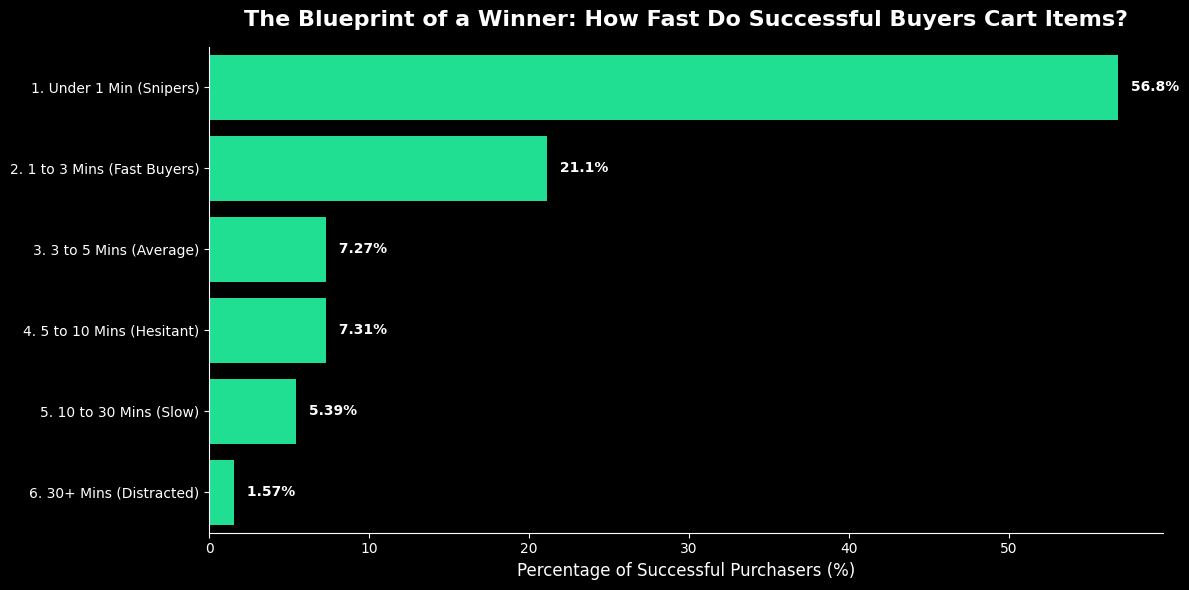

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for the portfolio
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. THE CRITICAL FILTER (ONLY PURCHASERS)
# ==========================================
# Adjust the column name below based on how your dataframe flags purchasers.
# Based on your image, it might be df['User Segment'] == '3. Purchaser' or df['has_purchase'] == 1.
purchasers_df = df[df['has_purchase'] == 1]

print(f"Filtered down to {len(purchasers_df):,} successful purchasers.")

# Extract the time column and convert to minutes
cart_times = purchasers_df['time_to_cart_sec'].dropna()
time_in_mins = cart_times / 60

# ==========================================
# 3. CREATE THE DISCRETE BUCKETS
# ==========================================
bins = [0, 1, 3, 5, 10, 30, np.inf]
labels = [
    '1. Under 1 Min (Snipers)',
    '2. 1 to 3 Mins (Fast Buyers)',
    '3. 3 to 5 Mins (Average)',
    '4. 5 to 10 Mins (Hesitant)',
    '5. 10 to 30 Mins (Slow)',
    '6. 30+ Mins (Distracted)'
]

bucketed_data = pd.cut(time_in_mins, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
bucket_counts = bucketed_data.value_counts().reset_index()
bucket_counts.columns = ['Time Bucket', 'Purchaser Count']

total_purchasers = len(cart_times)
bucket_counts['% of Total Purchasers'] = (bucket_counts['Purchaser Count'] / total_purchasers * 100).round(2)

# Sort from fastest to slowest
bucket_counts = bucket_counts.sort_values('Time Bucket').reset_index(drop=True)

print("\n" + "="*70)
print("SUCCESSFUL PURCHASER TIME DISTRIBUTION (ADDS UP TO 100%)")
print("="*70)
print(bucket_counts.to_string(index=False))
print("="*70)

# ==========================================
# 5. THE DASHBOARD VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=bucket_counts,
    x='% of Total Purchasers',
    y='Time Bucket',
    color='#00ff99' # Using a 'Success Green' color
)

plt.title('The Blueprint of a Winner: How Fast Do Successful Buyers Cart Items?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Successful Purchasers (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the bars
for index, value in enumerate(bucket_counts['% of Total Purchasers']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

sns.despine()
plt.tight_layout()
plt.show()

# Category Focus

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

SUCCESSFUL PURCHASER CATEGORY DISTRIBUTION (ADDS UP TO 100%)
                     Category Bucket  Purchaser Count  % of Total Purchasers
      1. Exactly 1 Category (Sniper)           227137                  87.08
   2. Exactly 2 Categories (Focused)            25203                   9.66
  3. Exactly 3 Categories (Browsing)             5699                   2.18
4. Exactly 4 Categories (Distracted)             1681                   0.64
   5. 5+ Categories (Window Shopper)             1113                   0.43


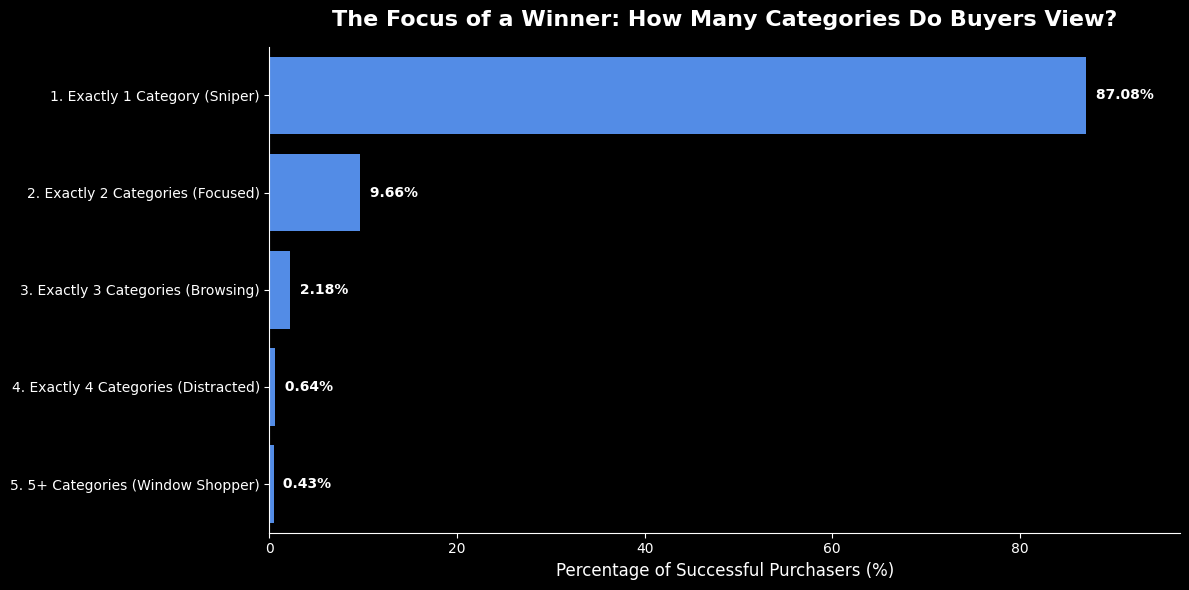

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for the portfolio
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. THE CRITICAL FILTER (ONLY PURCHASERS)
# ==========================================
# Isolate only the users who successfully completed a purchase
purchasers_df = df[df['has_purchase'] == 1]

# Extract the category count column
# (Ensure the column name exactly matches your dataframe)
cat_col = 'unique_categories_viewed'
category_counts = purchasers_df[cat_col].dropna()

# ==========================================
# 3. CREATE THE DISCRETE BUCKETS
# ==========================================
# For integers, pd.cut uses (start, end].
# (0, 1] means exactly 1. (1, 2] means exactly 2.
bins = [0, 1, 2, 3, 4, np.inf]
labels = [
    '1. Exactly 1 Category (Sniper)',
    '2. Exactly 2 Categories (Focused)',
    '3. Exactly 3 Categories (Browsing)',
    '4. Exactly 4 Categories (Distracted)',
    '5. 5+ Categories (Window Shopper)'
]

bucketed_cats = pd.cut(category_counts, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
bucket_summary = bucketed_cats.value_counts().reset_index()
bucket_summary.columns = ['Category Bucket', 'Purchaser Count']

total_purchasers = len(category_counts)
bucket_summary['% of Total Purchasers'] = (bucket_summary['Purchaser Count'] / total_purchasers * 100).round(2)

# Sort logically from 1 to 5+
bucket_summary = bucket_summary.sort_values('Category Bucket').reset_index(drop=True)

print("\n" + "="*75)
print("SUCCESSFUL PURCHASER CATEGORY DISTRIBUTION (ADDS UP TO 100%)")
print("="*75)
print(bucket_summary.to_string(index=False))
print("="*75)

# ==========================================
# 5. THE DASHBOARD VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=bucket_summary,
    x='% of Total Purchasers',
    y='Category Bucket',
    color='#3a86ff' # A sharp corporate blue for this metric
)

plt.title('The Focus of a Winner: How Many Categories Do Buyers View?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Successful Purchasers (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the bars
for index, value in enumerate(bucket_summary['% of Total Purchasers']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

# Extend X-axis so labels fit nicely
plt.xlim(0, bucket_summary['% of Total Purchasers'].max() + 10)

sns.despine()
plt.tight_layout()
plt.show()

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

SUCCESSFUL PURCHASER POST-CART VIEW DISTRIBUTION (ADDS UP TO 100%)
             Post-Cart Views Bucket  Purchaser Count  % of Total Purchasers
     0 Views (Straight to Checkout)            81589                  31.28
Exactly 1 View (Quick Double-Check)            82885                  31.78
 Exactly 2 Views (Minor Hesitation)            34415                  13.19
Exactly 3 Views (Comparing Options)            18492                   7.09
       Exactly 4 Views (Distracted)            11288                   4.33
      5+ Views (Severe Distraction)            32164                  12.33


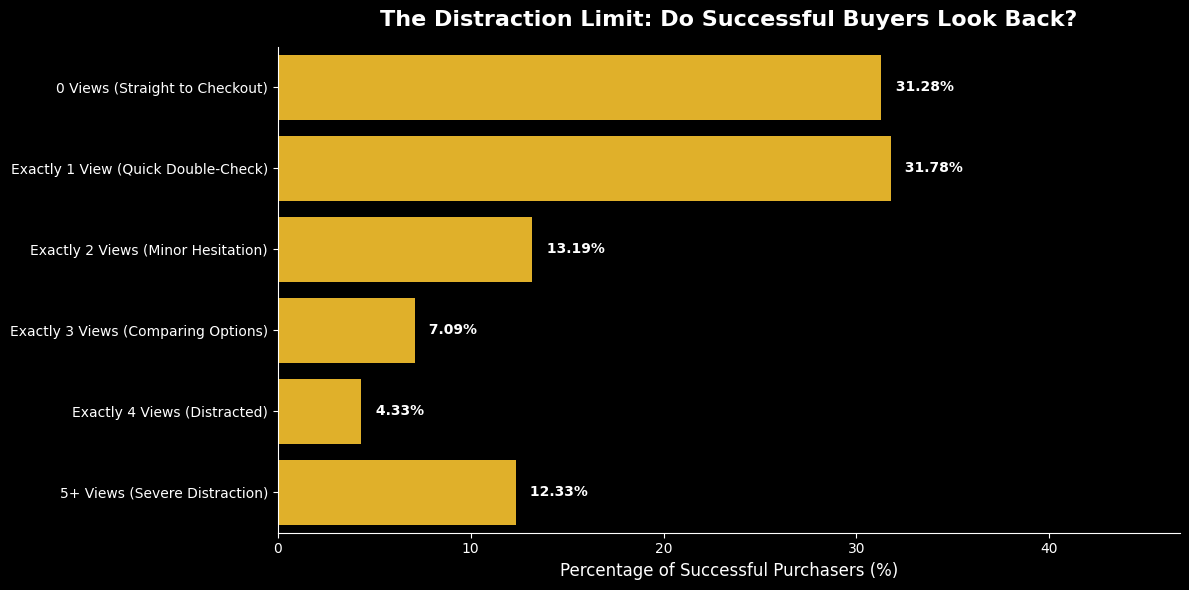

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for the portfolio dashboard
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. THE CRITICAL FILTER (ONLY PURCHASERS)
# ==========================================
purchasers_df = df[df['has_purchase'] == 1]

# Extract the views after cart column
# (Ensure the column name exactly matches your dataframe)
view_col = 'views_after_cart'
post_cart_views = purchasers_df[view_col].dropna()

# ==========================================
# 3. CREATE THE DISCRETE BUCKETS
# ==========================================
# For pd.cut with integers, bins like (-1, 0] capture exactly 0.
# (0, 1] captures exactly 1.
bins = [-1, 0, 1, 2, 3, 4, np.inf]
labels = [
    '0 Views (Straight to Checkout)',
    'Exactly 1 View (Quick Double-Check)',
    'Exactly 2 Views (Minor Hesitation)',
    'Exactly 3 Views (Comparing Options)',
    'Exactly 4 Views (Distracted)',
    '5+ Views (Severe Distraction)'
]

bucketed_views = pd.cut(post_cart_views, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
bucket_summary = bucketed_views.value_counts().reset_index()
bucket_summary.columns = ['Post-Cart Views Bucket', 'Purchaser Count']

total_purchasers = len(post_cart_views)
bucket_summary['% of Total Purchasers'] = (bucket_summary['Purchaser Count'] / total_purchasers * 100).round(2)

# Sort logically from 0 to 5+
bucket_summary = bucket_summary.sort_values('Post-Cart Views Bucket').reset_index(drop=True)

print("\n" + "="*75)
print("SUCCESSFUL PURCHASER POST-CART VIEW DISTRIBUTION (ADDS UP TO 100%)")
print("="*75)
print(bucket_summary.to_string(index=False))
print("="*75)

# ==========================================
# 5. THE DASHBOARD VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=bucket_summary,
    x='% of Total Purchasers',
    y='Post-Cart Views Bucket',
    color='#ffbe0b' # A sharp gold color to distinguish from the previous charts
)

plt.title('The Distraction Limit: Do Successful Buyers Look Back?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Successful Purchasers (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the bars
for index, value in enumerate(bucket_summary['% of Total Purchasers']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

# Extend X-axis so labels fit
plt.xlim(0, bucket_summary['% of Total Purchasers'].max() + 15)

sns.despine()
plt.tight_layout()
plt.show()

# cart abdendor

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...
Filtered down to 260,825 cart abandoners.

CART ABANDONER TIME DISTRIBUTION (ADDS UP TO 100%)
                                      Time Bucket  Abandoner Count  % of Total Abandoners
                 1. Under 1 Min (Fast Hesitators)           112546                  43.18
              2. 1 to 3 Mins (Average Hesitators)            67629                  25.95
                 3. 3 to 5 Mins (Slow Hesitators)            25900                   9.94
4. 5 to 10 Mins (Transitioning to Window Shopper)            26659                  10.23
               5. 10 to 30 Mins (Window Shoppers)            20614                   7.91
              6. 30+ Mins (Wishlist / Distracted)             6395                   2.45


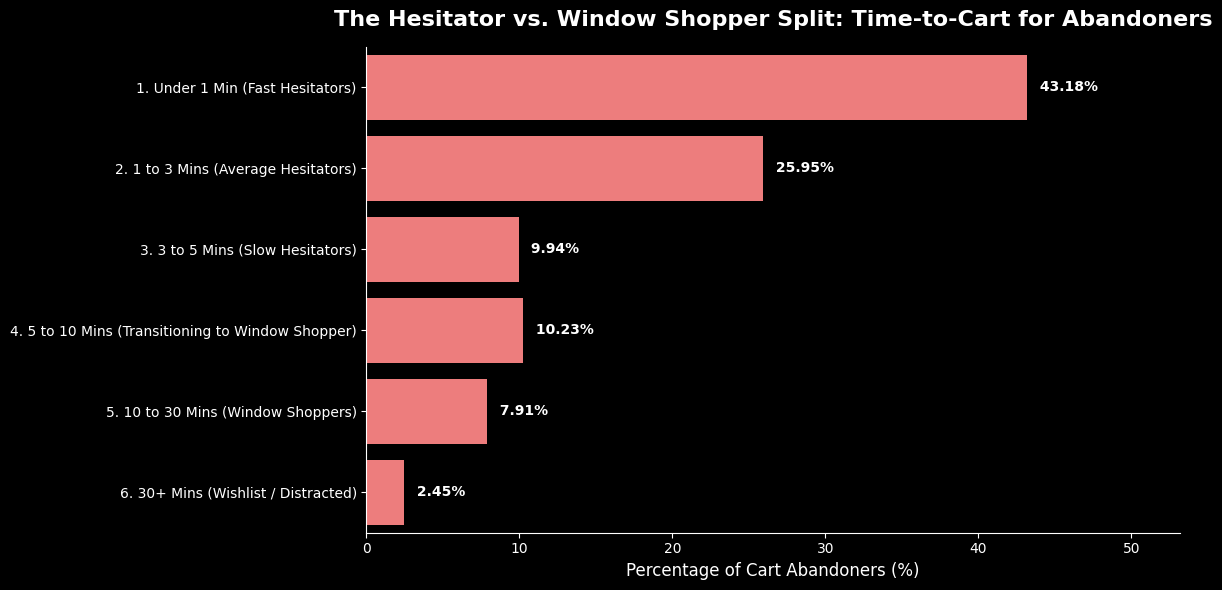

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for the portfolio dashboard
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. THE CRITICAL FILTER (ONLY ABANDONERS)
# ==========================================
# Isolate only the users who FAILED to complete a purchase
abandoners_df = df[df['has_purchase'] == 0]

print(f"Filtered down to {len(abandoners_df):,} cart abandoners.")

# Extract the time column and convert to minutes
cart_times = abandoners_df['time_to_cart_sec'].dropna()
time_in_mins = cart_times / 60

# ==========================================
# 3. CREATE THE DISCRETE BUCKETS
# ==========================================
bins = [0, 1, 3, 5, 10, 30, np.inf]
labels = [
    '1. Under 1 Min (Fast Hesitators)',
    '2. 1 to 3 Mins (Average Hesitators)',
    '3. 3 to 5 Mins (Slow Hesitators)',
    '4. 5 to 10 Mins (Transitioning to Window Shopper)',
    '5. 10 to 30 Mins (Window Shoppers)',
    '6. 30+ Mins (Wishlist / Distracted)'
]

bucketed_data = pd.cut(time_in_mins, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
bucket_counts = bucketed_data.value_counts().reset_index()
bucket_counts.columns = ['Time Bucket', 'Abandoner Count']

total_abandoners = len(cart_times)
bucket_counts['% of Total Abandoners'] = (bucket_counts['Abandoner Count'] / total_abandoners * 100).round(2)

# Sort from fastest to slowest
bucket_counts = bucket_counts.sort_values('Time Bucket').reset_index(drop=True)

print("\n" + "="*70)
print("CART ABANDONER TIME DISTRIBUTION (ADDS UP TO 100%)")
print("="*70)
print(bucket_counts.to_string(index=False))
print("="*70)

# ==========================================
# 5. THE DASHBOARD VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Using a distinct color (coral/red) to indicate these are lost sales
ax = sns.barplot(
    data=bucket_counts,
    x='% of Total Abandoners',
    y='Time Bucket',
    color='#ff6b6b'
)

plt.title('The Hesitator vs. Window Shopper Split: Time-to-Cart for Abandoners', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Cart Abandoners (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the bars
for index, value in enumerate(bucket_counts['% of Total Abandoners']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

# Extend X-axis slightly for labels
plt.xlim(0, bucket_counts['% of Total Abandoners'].max() + 10)

sns.despine()
plt.tight_layout()
plt.show()

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

ABANDONER CATEGORY DISTRIBUTION (ADDS UP TO 100%)
                             Category Bucket  Abandoner Count  % of Total Abandoners
   1. Exactly 1 Category (Focused Hesitator)           216991                  83.19
 2. Exactly 2 Categories (Comparing 2 Items)            29572                  11.34
      3. Exactly 3 Categories (Losing Focus)             8456                   3.24
        4. Exactly 4 Categories (Distracted)             3224                   1.24
5. 5+ Categories (Window Shopper / Wishlist)             2582                   0.99


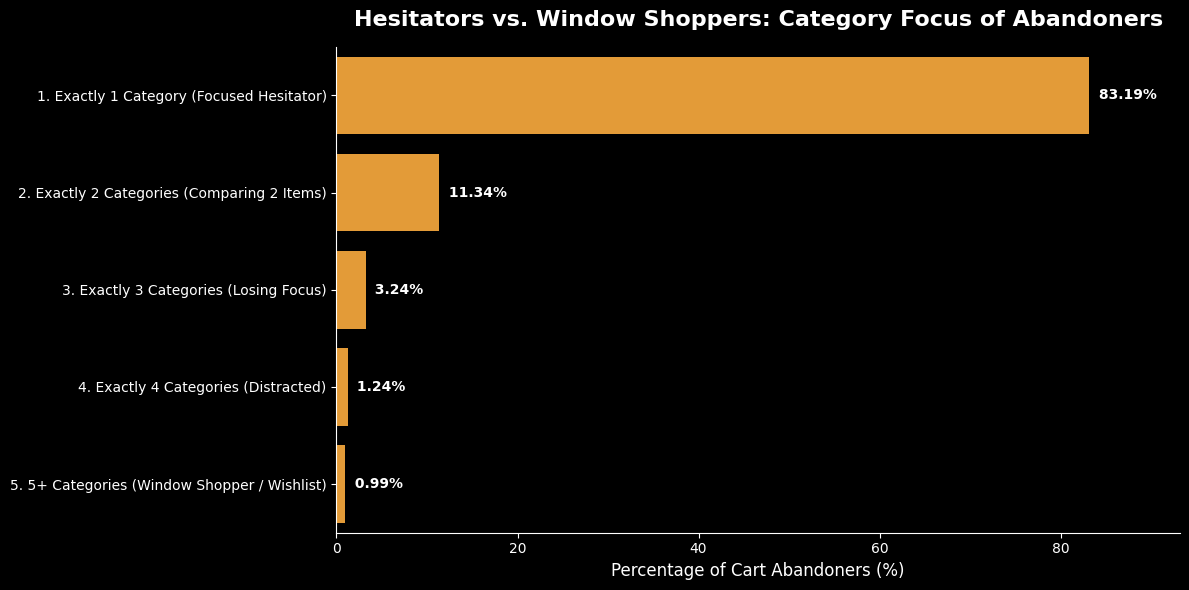

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. FILTER FOR ABANDONERS ONLY
# ==========================================
abandoners_df = df[df['has_purchase'] == 0]

# Extract the category count column
cat_col = 'unique_categories_viewed'
category_counts = abandoners_df[cat_col].dropna()

# ==========================================
# 3. CREATE DISCRETE BUCKETS
# ==========================================
bins = [0, 1, 2, 3, 4, np.inf]
labels = [
    '1. Exactly 1 Category (Focused Hesitator)',
    '2. Exactly 2 Categories (Comparing 2 Items)',
    '3. Exactly 3 Categories (Losing Focus)',
    '4. Exactly 4 Categories (Distracted)',
    '5. 5+ Categories (Window Shopper / Wishlist)'
]

bucketed_cats = pd.cut(category_counts, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE PERCENTAGES (THE TABLE)
# ==========================================
bucket_summary = bucketed_cats.value_counts().reset_index()
bucket_summary.columns = ['Category Bucket', 'Abandoner Count']

total_abandoners = len(category_counts)
bucket_summary['% of Total Abandoners'] = (bucket_summary['Abandoner Count'] / total_abandoners * 100).round(2)

# Sort logically
bucket_summary = bucket_summary.sort_values('Category Bucket').reset_index(drop=True)

print("\n" + "="*75)
print("ABANDONER CATEGORY DISTRIBUTION (ADDS UP TO 100%)")
print("="*75)
print(bucket_summary.to_string(index=False))
print("="*75)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Using an orange/red hue to indicate lost sales
ax = sns.barplot(
    data=bucket_summary,
    x='% of Total Abandoners',
    y='Category Bucket',
    color='#ff9f1c'
)

plt.title('Hesitators vs. Window Shoppers: Category Focus of Abandoners', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Cart Abandoners (%)', fontsize=12)
plt.ylabel('')

for index, value in enumerate(bucket_summary['% of Total Abandoners']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

plt.xlim(0, bucket_summary['% of Total Abandoners'].max() + 10)
sns.despine()
plt.tight_layout()
plt.show()

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

ABANDONER PRE-CART RESEARCH DISTRIBUTION (ADDS UP TO 100%)
               Pre-Cart Views Bucket  Abandoner Count  % of Total Abandoners
1. Exactly 1 View (The Impulse Cart)           117946                  45.22
  2. 2 to 3 Views (Focused Research)            71720                  27.50
  3. 4 to 6 Views (Heavy Comparison)            35792                  13.72
     4. 7 to 10 Views (Losing Focus)            17582                   6.74
  5. 11+ Views (Pure Window Shopper)            16702                   6.40


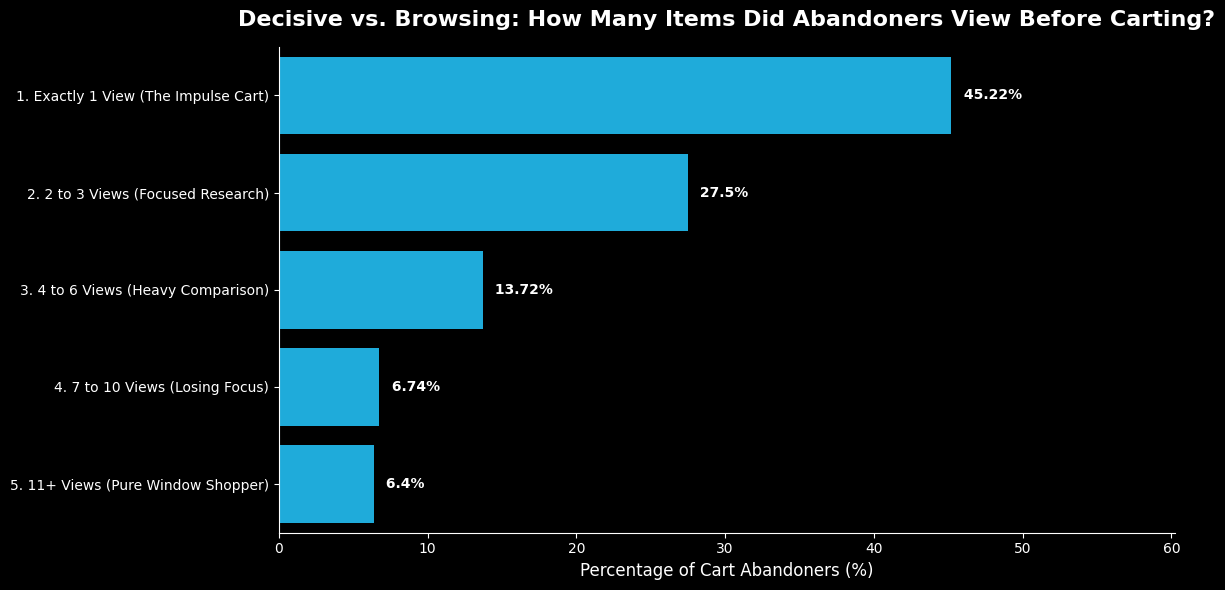

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for the portfolio dashboard
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. THE CRITICAL FILTER (ONLY ABANDONERS)
# ==========================================
# Isolate only the users who FAILED to complete a purchase
abandoners_df = df[df['has_purchase'] == 0]

# Extract the views before cart column
# (Ensure the column name exactly matches what is in your parquet file)
view_col = 'views_before_cart'

# Drop nulls just in case
pre_cart_views = abandoners_df[view_col].dropna()

# ==========================================
# 3. CREATE THE DISCRETE BUCKETS
# ==========================================
# For pd.cut with integers, (0, 1] means exactly 1.
bins = [0, 1, 3, 6, 10, np.inf]
labels = [
    '1. Exactly 1 View (The Impulse Cart)',
    '2. 2 to 3 Views (Focused Research)',
    '3. 4 to 6 Views (Heavy Comparison)',
    '4. 7 to 10 Views (Losing Focus)',
    '5. 11+ Views (Pure Window Shopper)'
]

bucketed_views = pd.cut(pre_cart_views, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
bucket_summary = bucketed_views.value_counts().reset_index()
bucket_summary.columns = ['Pre-Cart Views Bucket', 'Abandoner Count']

total_abandoners = len(pre_cart_views)
bucket_summary['% of Total Abandoners'] = (bucket_summary['Abandoner Count'] / total_abandoners * 100).round(2)

# Sort logically from least views to most views
bucket_summary = bucket_summary.sort_values('Pre-Cart Views Bucket').reset_index(drop=True)

print("\n" + "="*80)
print("ABANDONER PRE-CART RESEARCH DISTRIBUTION (ADDS UP TO 100%)")
print("="*80)
print(bucket_summary.to_string(index=False))
print("="*80)

# ==========================================
# 5. THE DASHBOARD VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Using a distinct teal/cyan color to separate this metric from the others
ax = sns.barplot(
    data=bucket_summary,
    x='% of Total Abandoners',
    y='Pre-Cart Views Bucket',
    color='#00bbf9'
)

plt.title('Decisive vs. Browsing: How Many Items Did Abandoners View Before Carting?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Cart Abandoners (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the bars
for index, value in enumerate(bucket_summary['% of Total Abandoners']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

# Extend X-axis slightly for labels
plt.xlim(0, bucket_summary['% of Total Abandoners'].max() + 15)

sns.despine()
plt.tight_layout()
plt.show()

Loading data from: /content/drive/MyDrive/A_CART/final_result2.parquet...

ABANDONER PRE-CART RESEARCH DISTRIBUTION (ADDS UP TO 100%)
               Pre-Cart Views Bucket  Abandoner Count  % of Total Abandoners
1. Exactly 1 View (The Impulse Cart)           141571                  54.28
  2. 2 to 3 Views (Focused Research)            64528                  24.74
  3. 4 to 6 Views (Heavy Comparison)            27685                  10.61
     4. 7 to 10 Views (Losing Focus)            12773                   4.90
  5. 11+ Views (Pure Window Shopper)            12473                   4.78


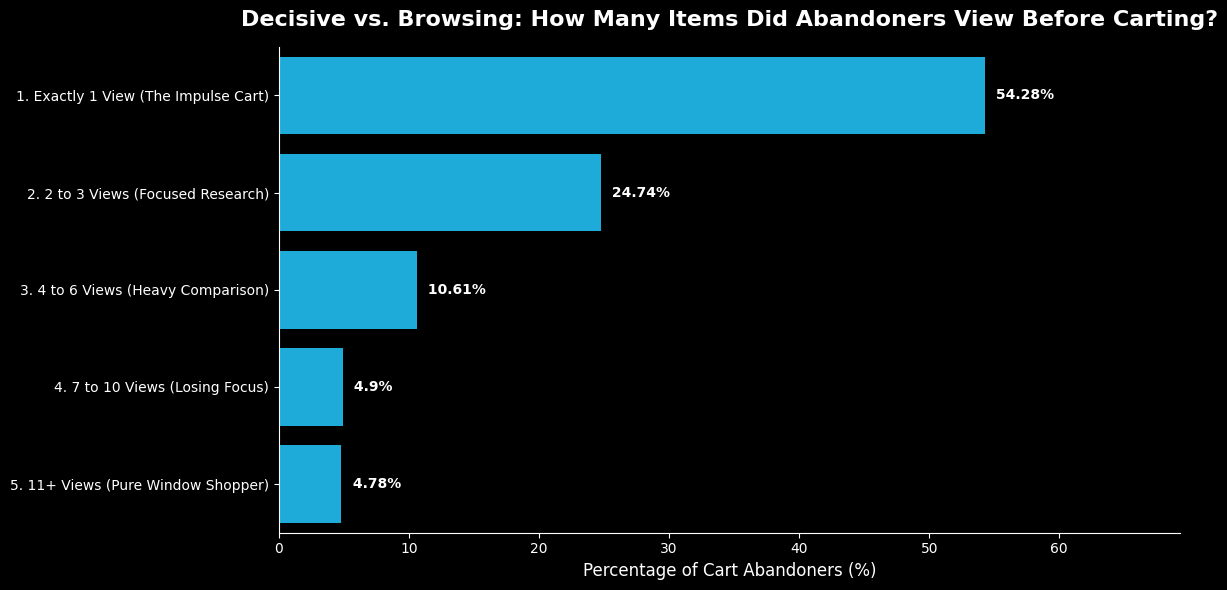

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for the portfolio dashboard
plt.style.use('dark_background')

# 1. Load the data
file_path = '/content/drive/MyDrive/A_CART/final_result2.parquet'
print(f"Loading data from: {file_path}...")
df = pd.read_parquet(file_path)

# ==========================================
# 2. THE CRITICAL FILTER (ONLY ABANDONERS)
# ==========================================
# Isolate only the users who FAILED to complete a purchase
abandoners_df = df[df['has_purchase'] == 1]

# Extract the views before cart column
# (Ensure the column name exactly matches what is in your parquet file)
view_col = 'views_before_cart'

# Drop nulls just in case
pre_cart_views = abandoners_df[view_col].dropna()

# ==========================================
# 3. CREATE THE DISCRETE BUCKETS
# ==========================================
# For pd.cut with integers, (0, 1] means exactly 1.
bins = [0, 1, 3, 6, 10, np.inf]
labels = [
    '1. Exactly 1 View (The Impulse Cart)',
    '2. 2 to 3 Views (Focused Research)',
    '3. 4 to 6 Views (Heavy Comparison)',
    '4. 7 to 10 Views (Losing Focus)',
    '5. 11+ Views (Pure Window Shopper)'
]

bucketed_views = pd.cut(pre_cart_views, bins=bins, labels=labels)

# ==========================================
# 4. CALCULATE THE PERCENTAGES (THE TABLE)
# ==========================================
bucket_summary = bucketed_views.value_counts().reset_index()
bucket_summary.columns = ['Pre-Cart Views Bucket', 'Abandoner Count']

total_abandoners = len(pre_cart_views)
bucket_summary['% of Total Abandoners'] = (bucket_summary['Abandoner Count'] / total_abandoners * 100).round(2)

# Sort logically from least views to most views
bucket_summary = bucket_summary.sort_values('Pre-Cart Views Bucket').reset_index(drop=True)

print("\n" + "="*80)
print("ABANDONER PRE-CART RESEARCH DISTRIBUTION (ADDS UP TO 100%)")
print("="*80)
print(bucket_summary.to_string(index=False))
print("="*80)

# ==========================================
# 5. THE DASHBOARD VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Using a distinct teal/cyan color to separate this metric from the others
ax = sns.barplot(
    data=bucket_summary,
    x='% of Total Abandoners',
    y='Pre-Cart Views Bucket',
    color='#00bbf9'
)

plt.title('Decisive vs. Browsing: How Many Items Did Abandoners View Before Carting?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage of Cart Abandoners (%)', fontsize=12)
plt.ylabel('')

# Add the exact percentage text on the bars
for index, value in enumerate(bucket_summary['% of Total Abandoners']):
    plt.text(value + 0.5, index, f' {value}%', va='center', fontweight='bold', color='white')

# Extend X-axis slightly for labels
plt.xlim(0, bucket_summary['% of Total Abandoners'].max() + 15)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
q=f"""
select *
from '{next_path}'
limit 2
"""


result = duckdb.query(q).df()
result

,user_id,user_session,has_view,has_cart,has_purchase,total_viewed_value,net_cart_value,total_purchased_value,views_before_cart,views_after_cart,unique_categories_viewed,time_to_cart_sec,is_premium_shopper,time_to_cart_formatted
0,521357357,00837a4b-32c3-4232-9b2f-fe59fdfa21b6,1,1,0,575.79,575.79,0.0,1.0,0.0,1,7,0,0d:00h:00m:07s
1,513236715,0133b664-e594-4e0e-bc63-24ca27f45766,1,1,0,49.44,49.44,0.0,1.0,3.0,1,52,0,0d:00h:01m:52s


In [ ]:

# 2. The DuckDB SQL Query with Nested Logic
query = f"""
SELECT
    *,
    CASE
        -- ==========================================
        -- PART 1: THE BUYER LOGIC (has_purchase = 1)
        -- ==========================================
        WHEN has_purchase = 1 THEN
            CASE
                -- Your Safe Buyer thresholds
                WHEN time_to_cart_sec < 180
                 AND unique_categories_viewed <= 1
                 AND views_after_cart <= 1

                THEN 'Safe Buyer'

                -- Anyone who buys but fails the test above
                ELSE 'Hesitate Buyer (Purchased)'
            END

        -- ==========================================
        -- PART 2: THE ABANDONER LOGIC (has_purchase = 0)
        -- ==========================================
        WHEN has_purchase = 0 THEN
            CASE
                -- Your Hesitator thresholds
                WHEN time_to_cart_sec < 300
                 AND unique_categories_viewed <= 3
                 AND views_before_cart <= 6

                THEN 'Hesitate Buyer (Abandoned)'

                -- Anyone who abandons and fails the test above
                ELSE 'Window Shopper'
            END

    END AS status

FROM '{next_path}'
"""

# 3. Execute the query directly into a Pandas DataFrame
df_tagged = duckdb.query(query).to_df()

# 4. Verify the results
print("\n" + "="*50)
print("TRIAGE STATUS DISTRIBUTION")
print("="*50)
print(df_tagged['status'].value_counts(dropna=False))

# Optional: Save the new dataset with the status column to use in your Dashboard
output_path = '/content/drive/MyDrive/A_CART/dashboard_ready_data.parquet'
df_tagged.to_parquet(output_path)
print(f"\nSaved dashboard-ready data to: {output_path}")


TRIAGE STATUS DISTRIBUTION
status
Hesitate Buyer (Abandoned)    198801
Hesitate Buyer (Purchased)    133493
Safe Buyer                    127340
Window Shopper                 62024
Name: count, dtype: int64

Saved dashboard-ready data to: /content/drive/MyDrive/A_CART/dashboard_ready_data.parquet


In [ ]:
ouput = '/content/drive/MyDrive/A_CART/dashboard_ready_data.parquet'

In [ ]:
q=f"""
select *
from '{ouput}'
limit 10 offset 20
"""


result = duckdb.query(q).df()
result

,user_id,user_session,has_view,has_cart,has_purchase,total_viewed_value,net_cart_value,total_purchased_value,views_before_cart,views_after_cart,unique_categories_viewed,time_to_cart_sec,is_premium_shopper,time_to_cart_formatted,status
0,562525971,0fec3051-cb26-4dce-a9b6-6f468501e95a,1,1,1,987.24,246.81,246.81,2.0,2.0,1,21,0,0d:00h:00m:21s,Hesitate Buyer (Purchased)
1,537538822,100366c9-6f98-4a0e-8ab9-9dadceac4e7a,1,1,1,1842.73,320.48,721.07,1.0,3.0,2,50,0,0d:00h:01m:50s,Hesitate Buyer (Purchased)
2,512475871,110e90cc-b741-4230-ba32-e850949feecb,1,1,0,1584.04,792.02,0.00,1.0,1.0,1,4,0,0d:00h:00m:04s,Hesitate Buyer (Abandoned)
3,562578199,1165ad93-1ada-4218-8597-1212958364e1,1,1,0,50.91,50.91,0.00,1.0,0.0,1,116,0,0d:00h:02m:56s,Hesitate Buyer (Abandoned)
4,560967647,11a32fa1-8d97-4100-8627-c009c0ea30d6,1,1,0,7091.30,723.12,0.00,2.0,12.0,2,69,0,0d:00h:01m:09s,Hesitate Buyer (Abandoned)
5,559036873,1206247d-66e8-467f-9f97-d041c9728b36,1,1,1,391.44,130.48,130.48,1.0,2.0,1,16,0,0d:00h:00m:16s,Hesitate Buyer (Purchased)
6,518085395,126fce4e-6439-44db-9ae8-560a8e402a93,1,1,0,394.53,526.04,0.00,1.0,2.0,1,23,0,0d:00h:00m:23s,Hesitate Buyer (Abandoned)
7,513983313,127cc28c-d2ee-4f26-b69b-6033ffbc0fc2,1,1,0,4739.65,1492.34,0.00,1.0,5.0,1,53,0,0d:00h:01m:53s,Hesitate Buyer (Abandoned)
8,521728715,12d71619-966d-4899-91a9-61b8a9e8061b,1,1,1,1042.50,1042.50,521.25,1.0,1.0,1,18,0,0d:00h:00m:18s,Safe Buyer
9,514961194,12ecfce6-1fb7-4ed7-9c93-595be0b49bf5,1,1,1,230.85,230.85,230.85,1.0,0.0,1,98,0,0d:00h:02m:38s,Safe Buyer
